# Laboratorio 2: Caracterización del Ruido en un Canal de Comunicaciones Inalámbrico

## Objetivo

El objetivo de esta práctica es caracterizar el ruido presente en todo canal de comunicaciones inalámbrico. Para ello, se utilizará la Radio Definida por Software (SDR) para extraer las componentes en fase (parte real) y en cuadratura (parte imaginaria) de la señal recibida por el receptor, **cuando el mismo no se encuentra transmitiendo ningún tipo de señal**.

De esta forma, la señal capturada corresponderá exclusivamente al **ruido del canal y del receptor**, permitiéndonos analizar sus propiedades estadísticas.

### Contenido
1. Instalación de dependencias
2. Configuración del SDR
3. Captura de muestras de ruido
4. Gráficas en tiempo y frecuencia
5. Media y varianza
6. Histograma
7. Histograma normalizado
8. Superposición con PDF gaussiana teórica
9. Análisis de gaussianidad (gráfico Q-Q)
10. Generación de variable gaussiana compleja sintética
11. Conclusiones

---
## 1. Instalación de dependencias

Instalamos las bibliotecas necesarias para el desarrollo del laboratorio:
- **pyadi-iio**: Interfaz Python para interactuar con el SDR (PlutoSDR).
- **numpy**: Operaciones numéricas y generación de señales.
- **matplotlib**: Visualización de gráficos.
- **scipy**: Funciones estadísticas (distribución normal, etc.).
- **statsmodels**: Para el gráfico Q-Q (qqplot).

In [1]:
# Instalación de las bibliotecas necesarias
# pyadi-iio: interfaz de alto nivel para controlar el SDR desde Python
# scipy: funciones estadísticas y de procesamiento de señales
# statsmodels: herramientas estadísticas avanzadas (incluye qqplot)
%pip install pyadi-iio matplotlib scipy statsmodels numpy

Note: you may need to restart the kernel to use updated packages.


---
## 2. Importación de bibliotecas

Importamos todas las bibliotecas que utilizaremos a lo largo del laboratorio.

In [15]:
# ========================================================================================
# Importación de bibliotecas
# ========================================================================================

import adi                          # Interfaz para controlar el SDR (PlutoSDR)
import numpy as np                  # Operaciones numéricas y manejo de arreglos
import matplotlib.pyplot as plt     # Visualización de gráficos
from scipy import stats             # Funciones estadísticas (distribución normal, etc.)
from scipy.signal import welch      # Estimación de densidad espectral de potencia
from statsmodels.graphics.gofplots import qqplot  # Gráfico Q-Q para análisis de gaussianidad

# Configuración global de matplotlib para gráficos más grandes y legibles
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print("Bibliotecas importadas correctamente.")

Bibliotecas importadas correctamente.


---
## 3. Configuración del SDR

Configuramos el SDR con los parámetros indicados en la consigna del laboratorio. El objetivo es **escuchar el canal con la mínima interferencia posible**, para lo cual:

- **Loopback = 0**: Desactivamos el lazo de retorno para que el receptor capte señales externas (en este caso, ruido del canal).
- **Tx_cyclic_buffer = False**: No se utiliza buffer cíclico de transmisión ya que no estamos transmitiendo.
- **TxAtten = -70 dB**: Máxima atenuación en el transmisor para minimizar cualquier fuga de señal del Tx al Rx.
- **GainControlModes = "manual"**: Control de ganancia manual para tener control preciso sobre la sensibilidad del receptor.
- **RxHardwareGain = 70 dB**: Ganancia alta en el receptor para captar incluso las señales más débiles (el ruido).
- **RxBufferSize = 2^20**: Tamaño del buffer grande (1.048.576 muestras) para obtener una buena resolución estadística.

### Parámetros adicionales elegidos:
- **sample_rate = 2 MHz**: Frecuencia de muestreo de 2 millones de muestras por segundo.
- **rx_rf_bandwidth = 2 MHz**: Ancho de banda del filtro analógico del receptor.
- **tx_rf_bandwidth = 2 MHz**: Ancho de banda del filtro analógico del transmisor.
- **rx_lo = 915 MHz**: Frecuencia del oscilador local del receptor (banda ISM).
- **tx_lo = 2400 MHz**: Frecuencia del oscilador local del transmisor (diferente al Rx para evitar interferencia).

Nuestro limite es: 325 Mhz a 3.800 Mhz

> **Nota**: La URI se configura con la IP `192.168.1.34` correspondiente al SDR que se utilizará en esta práctica.

In [22]:
# ========================================================================================
# Parámetros de configuración del SDR
# ========================================================================================

# --- Parámetros indicados en la consigna ---
Uri                = "ip:192.168.1.33"    # Dirección IP del SDR
Loopback           = 0                     # Sin lazo de retorno (0=desactivado)
Tx_cyclic_buffer   = False                 # Sin buffer cíclico de Tx (no transmitimos)
TxAtten            = -70                   # Atenuación del transmisor [dB] (mínima potencia de Tx)
GainControlModes   = "manual"              # Control de ganancia manual
RxHardwareGain     = 70                    # Ganancia del receptor [dB] (máxima sensibilidad)
RxBufferSize       = 2**20                 # Tamaño del buffer de recepción (≈1M muestras)

# --- Parámetros adicionales elegidos por el usuario ---
samplingRate       = int(2e6)              # Frecuencia de muestreo: 2 MSPS
TxRfBw             = int(2e6)              # Ancho de banda RF del transmisor [Hz]
RxRfBw             = int(2e6)              # Ancho de banda RF del receptor [Hz]
TxLo               = int(350e6)           # Frecuencia portadora Tx: 2.4 GHz (alejada del Rx)
RxLo               = int(2000e6)            # Frecuencia portadora Rx: 915 MHz (banda ISM)

print(f"Parámetros de configuración definidos:")
print(f"  URI:                {Uri}")
print(f"  Loopback:           {Loopback}")
print(f"  Tx Cyclic Buffer:   {Tx_cyclic_buffer}")
print(f"  Tx Attenuation:     {TxAtten} dB")
print(f"  Gain Control Mode:  {GainControlModes}")
print(f"  Rx Hardware Gain:   {RxHardwareGain} dB")
print(f"  Rx Buffer Size:     {RxBufferSize} muestras")
print(f"  Sampling Rate:      {samplingRate/1e6} MSPS")
print(f"  Tx RF Bandwidth:    {TxRfBw/1e6} MHz")
print(f"  Rx RF Bandwidth:    {RxRfBw/1e6} MHz")
print(f"  Tx LO Frequency:    {TxLo/1e6} MHz")
print(f"  Rx LO Frequency:    {RxLo/1e6} MHz")

Parámetros de configuración definidos:
  URI:                ip:192.168.1.33
  Loopback:           0
  Tx Cyclic Buffer:   False
  Tx Attenuation:     -70 dB
  Gain Control Mode:  manual
  Rx Hardware Gain:   70 dB
  Rx Buffer Size:     1048576 muestras
  Sampling Rate:      2.0 MSPS
  Tx RF Bandwidth:    2.0 MHz
  Rx RF Bandwidth:    2.0 MHz
  Tx LO Frequency:    350.0 MHz
  Rx LO Frequency:    2000.0 MHz


### 3.1 Conexión y configuración del SDR

Creamos el objeto SDR y aplicamos todos los parámetros de configuración. El orden de configuración es importante:
1. Primero configuramos el lazo de retorno.
2. Luego la frecuencia de muestreo y anchos de banda.
3. Después las ganancias y modos de control.
4. Finalmente las frecuencias de los osciladores locales y el buffer.

In [24]:
# ========================================================================================
# Creación del objeto SDR y aplicación de la configuración
# ========================================================================================

# Crear el objeto SDR vinculado al dispositivo PlutoSDR en la IP indicada
sdr = adi.Pluto(Uri)
print(f"SDR conectado en: {Uri}")

# 1. Configurar el lazo de retorno (Loopback)
# Loopback=0: Sin lazo, el receptor capta señales del canal (antena)
sdr.loopback = Loopback

# 2. Configurar frecuencia de muestreo y anchos de banda de los filtros analógicos
sdr.sample_rate      = samplingRate       # Frecuencia de muestreo para Tx y Rx
sdr.tx_rf_bandwidth  = int(TxRfBw)        # Ancho de banda analógico del Tx
sdr.rx_rf_bandwidth  = int(RxRfBw)        # Ancho de banda analógico del Rx

# 3. Configurar ganancia del transmisor (atenuación) y del receptor
sdr.tx_hardwaregain_chan0   = TxAtten             # Atenuación del Tx: -70 dB (mínima potencia)
sdr.rx_hardwaregain_chan0   = RxHardwareGain      # Ganancia del Rx: 70 dB (máxima sensibilidad)
sdr.gain_control_mode_chan0 = GainControlModes    # Modo de control de ganancia: manual

# 4. Configurar las frecuencias de los osciladores locales
# Se elige una frecuencia de Tx muy diferente a la de Rx para evitar interferencias
sdr.tx_lo = TxLo  # Portadora Tx en 2.4 GHz
sdr.rx_lo = RxLo  # Portadora Rx en 915 MHz

# 5. Configurar el buffer de recepción
sdr.rx_buffer_size   = RxBufferSize       # Tamaño del buffer: 2^20 muestras
sdr.tx_cyclic_buffer = Tx_cyclic_buffer   # No usar buffer cíclico en Tx

print("\nConfiguración aplicada exitosamente.")
print(f"  Loopback:             {sdr.loopback}")
print(f"  Sample Rate:          {sdr.sample_rate}")
print(f"  Tx RF BW:             {sdr.tx_rf_bandwidth}")
print(f"  Rx RF BW:             {sdr.rx_rf_bandwidth}")
print(f"  Tx HW Gain:           {sdr.tx_hardwaregain_chan0}")
print(f"  Rx HW Gain:           {sdr.rx_hardwaregain_chan0}")
print(f"  Gain Control Mode:    {sdr.gain_control_mode_chan0}")
print(f"  Tx LO:                {sdr.tx_lo}")
print(f"  Rx LO:                {sdr.rx_lo}")
print(f"  Rx Buffer Size:       {sdr.rx_buffer_size}")

SDR conectado en: ip:192.168.1.33

Configuración aplicada exitosamente.
  Loopback:             0
  Sample Rate:          1999999
  Tx RF BW:             2000000
  Rx RF BW:             2000000
  Tx HW Gain:           -70
  Rx HW Gain:           70
  Gain Control Mode:    manual
  Tx LO:                349999998
  Rx LO:                1999999998
  Rx Buffer Size:       1048576


---
## 4. Captura de muestras de ruido

Con el SDR configurado y **sin transmitir señal alguna**, vamos a capturar las muestras que el receptor entrega. Dado que no hay transmisión activa, lo que se captura es esencialmente **ruido**:
- Ruido térmico del receptor
- Ruido del canal inalámbrico
- Posibles interferencias ambientales muy débiles

La señal recibida `rxSignal` es **compleja**: su parte real corresponde a la **componente en fase (I)** y su parte imaginaria a la **componente en cuadratura (Q)**.

Adicionalmente, dado que Tx no puede ser apagado completamente en el PlutoSDR, lo configuramos para transmitir ceros con mínima potencia y en una frecuencia alejada del receptor, minimizando así cualquier posible fuga.

In [25]:
# ========================================================================================
# Captura de muestras de ruido
# ========================================================================================

# Dado que no es posible apagar completamente el transmisor del PlutoSDR,
# lo configuramos para transmitir ceros con mínima potencia.
# Esto, junto con la máxima atenuación (-70 dB) y la frecuencia de Tx alejada
# de la de Rx, garantiza la mínima interferencia posible del Tx sobre el Rx.
sdr.tx_destroy_buffer()              # Destruir cualquier buffer de Tx previo
sdr.tx(np.zeros(2048))               # Transmitir ceros (señal nula)

# Realizar múltiples lecturas para estabilizar el receptor.
# Las primeras muestras pueden contener transitorios del hardware.
for i in range(5):
    _ = sdr.rx()  # Lecturas de descarte para estabilizar

# Captura definitiva de las muestras de ruido
rxSignal = sdr.rx()  # Señal compleja: I + jQ

# Extraer las componentes en fase (I) y en cuadratura (Q)
I = np.real(rxSignal)  # Componente en fase (parte real)
Q = np.imag(rxSignal)  # Componente en cuadratura (parte imaginaria)

# Información sobre la captura
N = len(rxSignal)  # Número total de muestras
Ts = 1 / samplingRate  # Período de muestreo [s]
T_total = N * Ts       # Duración total de la captura [s]

print(f"Captura realizada exitosamente.")
print(f"  Número de muestras:      {N}")
print(f"  Período de muestreo:     {Ts*1e6:.3f} µs")
print(f"  Duración de la captura:  {T_total*1e3:.3f} ms")
print(f"  Tipo de datos:           {rxSignal.dtype}")

Captura realizada exitosamente.
  Número de muestras:      1048576
  Período de muestreo:     0.500 µs
  Duración de la captura:  524.288 ms
  Tipo de datos:           complex128


---
## 5. Gráficas en tiempo y en frecuencia

### 5.1 Señal en el dominio del tiempo

Graficamos las componentes en fase (I) y en cuadratura (Q) de la señal recibida en función del tiempo. Al tratarse de ruido, esperamos ver una señal aleatoria fluctuando alrededor de cero sin ningún patrón periódico visible.

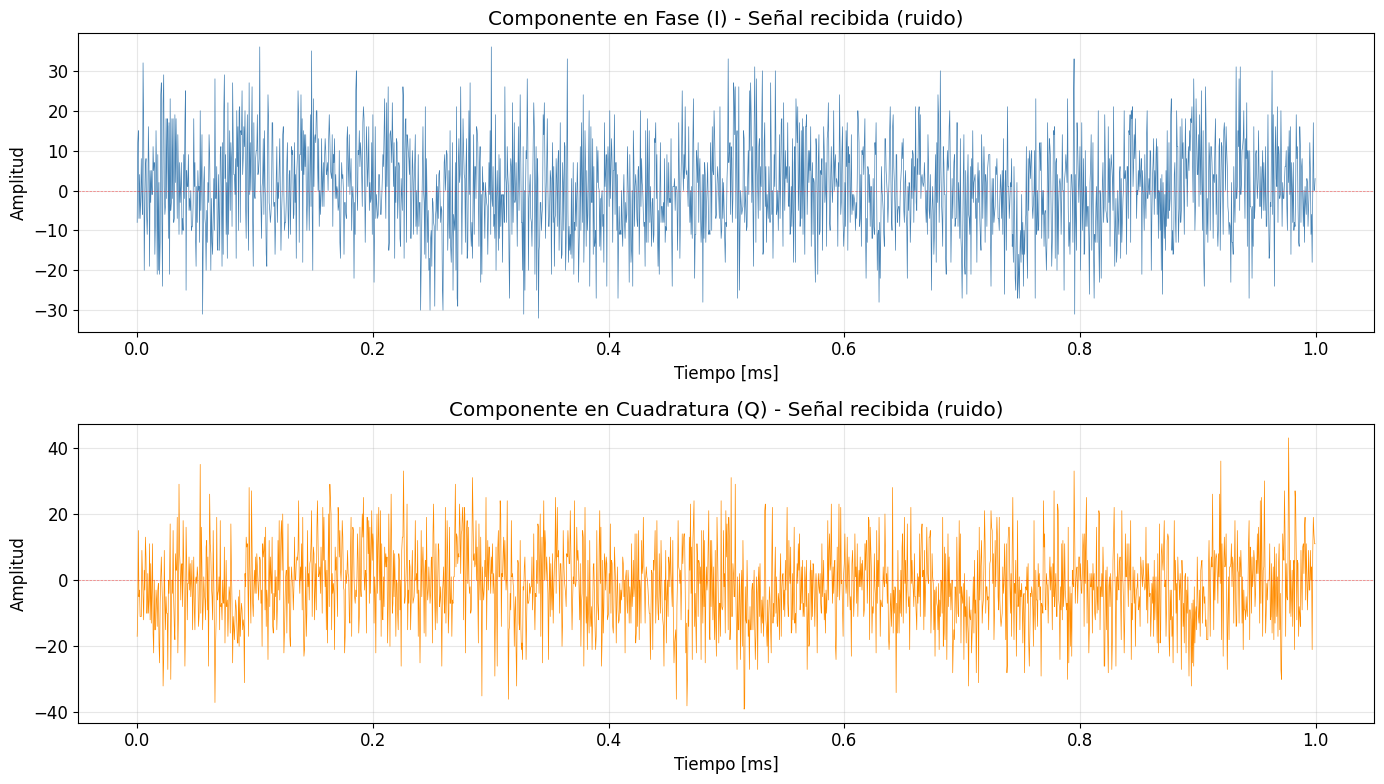

Se muestran las primeras 2000 muestras de un total de 1048576.


In [26]:
# ========================================================================================
# Gráfica de la señal en el dominio del tiempo
# ========================================================================================

# Creamos el vector de tiempo en milisegundos
t = np.arange(N) * Ts * 1e3  # Tiempo en ms

# Seleccionamos una porción de la señal para visualización (primeras 2000 muestras)
# ya que graficar todas las muestras (2^20) sería muy pesado y poco legible
n_display = 2000  # Cantidad de muestras a mostrar

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Componente en Fase (I) ---
axes[0].plot(t[:n_display], I[:n_display], linewidth=0.5, color='steelblue')
axes[0].set_xlabel('Tiempo [ms]')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Componente en Fase (I) - Señal recibida (ruido)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# --- Componente en Cuadratura (Q) ---
axes[1].plot(t[:n_display], Q[:n_display], linewidth=0.5, color='darkorange')
axes[1].set_xlabel('Tiempo [ms]')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Componente en Cuadratura (Q) - Señal recibida (ruido)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Se muestran las primeras {n_display} muestras de un total de {N}.")

### 5.2 Señal en el dominio de la frecuencia

Para analizar el contenido frecuencial de la señal, utilizamos dos métodos:
1. **FFT (Transformada Rápida de Fourier)**: Nos da el espectro de magnitud de la señal.
2. **PSD (Densidad Espectral de Potencia)** usando el método de Welch: Nos da una estimación más suavizada de la distribución de potencia en función de la frecuencia.

El ruido blanco gaussiano tiene idealmente un espectro plano (potencia constante en todas las frecuencias dentro del ancho de banda del sistema).

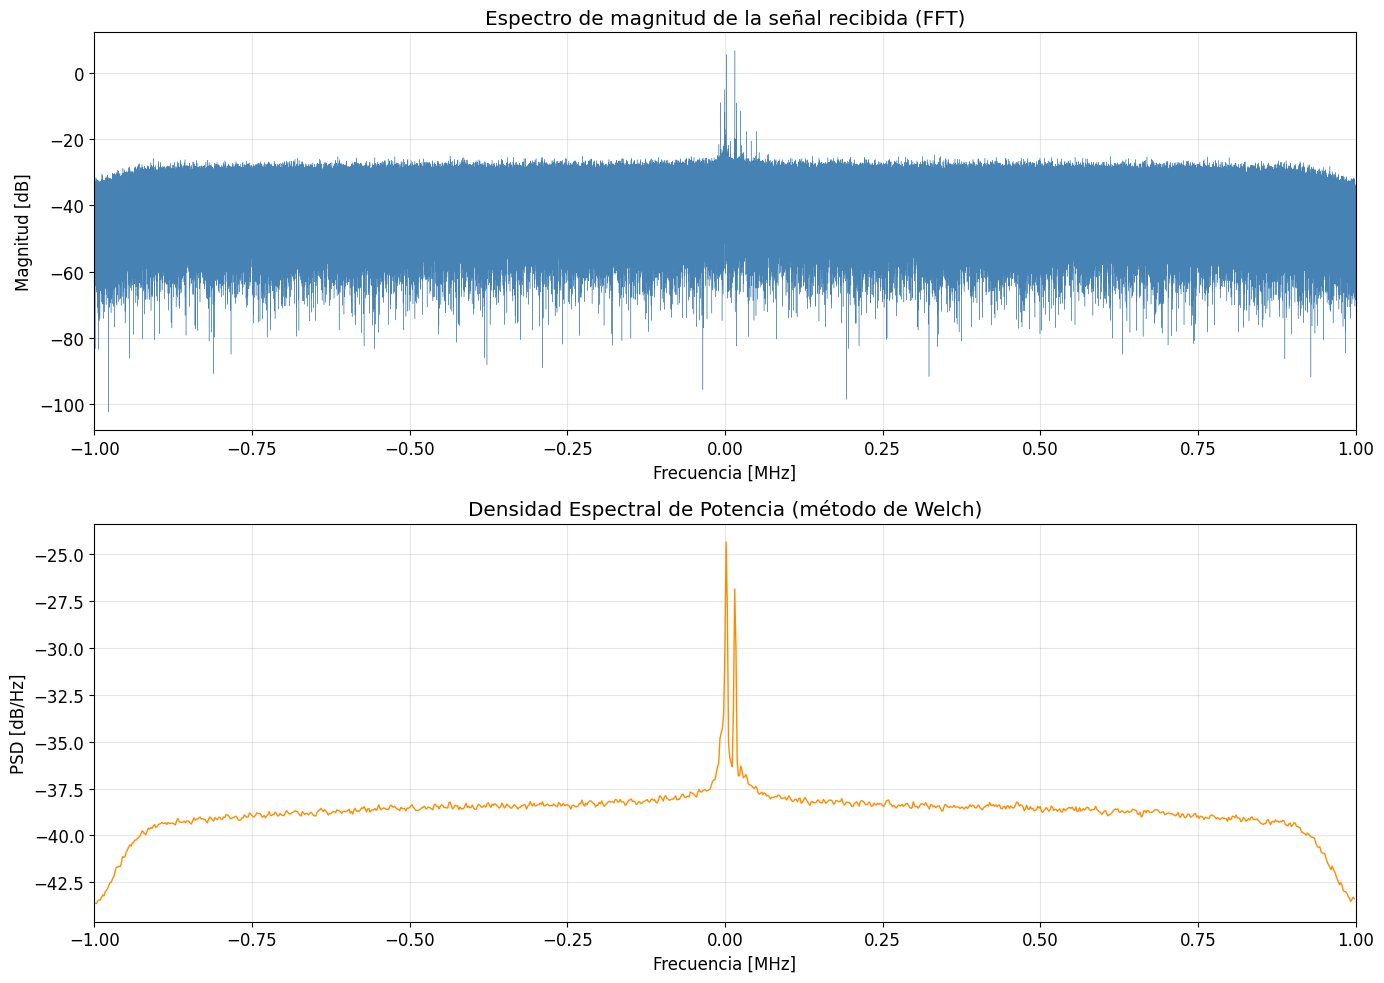

El espectro se muestra centrado en la frecuencia base (0 Hz).
La frecuencia real del centro del espectro es la del oscilador local del Rx: 2000.0 MHz


In [27]:
# ========================================================================================
# Gráfica de la señal en el dominio de la frecuencia
# ========================================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Espectro de magnitud usando FFT ---
# Calculamos la FFT de la señal compleja
# La señal es compleja (I + jQ), por lo que la FFT nos da el espectro bilateral
fft_signal = np.fft.fftshift(np.fft.fft(rxSignal))  # FFT centrada en 0
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=Ts))    # Vector de frecuencias [Hz]
freqs_MHz = freqs / 1e6  # Convertir a MHz

# Magnitud en dB (normalizada por el número de muestras)
magnitude_dB = 20 * np.log10(np.abs(fft_signal) / N + 1e-12)  # +1e-12 para evitar log(0)

axes[0].plot(freqs_MHz, magnitude_dB, linewidth=0.3, color='steelblue')
axes[0].set_xlabel('Frecuencia [MHz]')
axes[0].set_ylabel('Magnitud [dB]')
axes[0].set_title('Espectro de magnitud de la señal recibida (FFT)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-samplingRate/2/1e6, samplingRate/2/1e6])

# --- Densidad Espectral de Potencia (PSD) usando el método de Welch ---
# El método de Welch divide la señal en segmentos, calcula la FFT de cada uno
# y promedia, obteniendo una estimación más suavizada de la PSD
f_welch, psd_welch = welch(rxSignal, fs=samplingRate, nperseg=1024, 
                            return_onesided=False, scaling='density')

# Reordenar para centrar en 0
f_welch = np.fft.fftshift(f_welch) / 1e6  # Convertir a MHz
psd_welch = np.fft.fftshift(psd_welch)
psd_dB = 10 * np.log10(psd_welch + 1e-12)  # Convertir a dB

axes[1].plot(f_welch, psd_dB, linewidth=1.0, color='darkorange')
axes[1].set_xlabel('Frecuencia [MHz]')
axes[1].set_ylabel('PSD [dB/Hz]')
axes[1].set_title('Densidad Espectral de Potencia (método de Welch)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-samplingRate/2/1e6, samplingRate/2/1e6])

plt.tight_layout()
plt.show()

print("El espectro se muestra centrado en la frecuencia base (0 Hz).")
print("La frecuencia real del centro del espectro es la del oscilador local del Rx:", RxLo/1e6, "MHz")

---
## 6. Media y Varianza

Calculamos los estadísticos fundamentales de las componentes I y Q por separado:

- **Media ($\mu$)**: El valor esperado de la señal. Para ruido gaussiano de media cero, esperamos $\mu \approx 0$.
- **Varianza ($\sigma^2$)**: La dispersión de la señal alrededor de su media. Representa la potencia del ruido.
- **Desviación estándar ($\sigma$)**: La raíz cuadrada de la varianza.

En un sistema bien calibrado, ambas componentes (I y Q) deberían tener estadísticos similares, ya que el ruido es isotrópico.

In [38]:
# ========================================================================================
# Cálculo de la media y la varianza
# ========================================================================================

# --- Estadísticos de la componente en Fase (I) ---
mean_I = np.mean(I)
var_I  = np.var(I)
std_I  = np.std(I)

# --- Estadísticos de la componente en Cuadratura (Q) ---
mean_Q = np.mean(Q)
var_Q  = np.var(Q)
std_Q  = np.std(Q)

# --- Mostrar resultados ---
print("=" * 60)
print("ESTADÍSTICOS DE LA SEÑAL RECIBIDA (RUIDO)")
print("=" * 60)
print(f"\nComponente en Fase (I):")
print(f"  Media (μ_I):                  {mean_I:.4f}")
print(f"  Varianza (σ²_I):              {var_I:.4f}")
print(f"  Desviación estándar (σ_I):    {std_I:.4f}")
print(f"\nComponente en Cuadratura (Q):")
print(f"  Media (μ_Q):                  {mean_Q:.4f}")
print(f"  Varianza (σ²_Q):              {var_Q:.4f}")
print(f"  Desviación estándar (σ_Q):    {std_Q:.4f}")
print(f"\nNota: Para ruido gaussiano de media cero, se espera μ ≈ 0.")
print(f"       Ambas componentes deberían tener varianzas similares.")

ESTADÍSTICOS DE LA SEÑAL RECIBIDA (RUIDO)

Componente en Fase (I):
  Media (μ_I):                  -0.0315
  Varianza (σ²_I):              146.3669
  Desviación estándar (σ_I):    12.0982

Componente en Cuadratura (Q):
  Media (μ_Q):                  -0.0429
  Varianza (σ²_Q):              146.6647
  Desviación estándar (σ_Q):    12.1105

Nota: Para ruido gaussiano de media cero, se espera μ ≈ 0.
       Ambas componentes deberían tener varianzas similares.


---
## 7. Histograma

El histograma nos permite visualizar la **distribución empírica** de las muestras de ruido. Muestra cuántas veces cada rango de valores de amplitud aparece en los datos.

Si el ruido es gaussiano, esperamos que el histograma tenga forma de **campana de Gauss** (Bell curve), centrada en la media y con dispersión determinada por la desviación estándar.

Referencia: Ver página 485 del libro "Intro a los Sistemas de Comunicación".

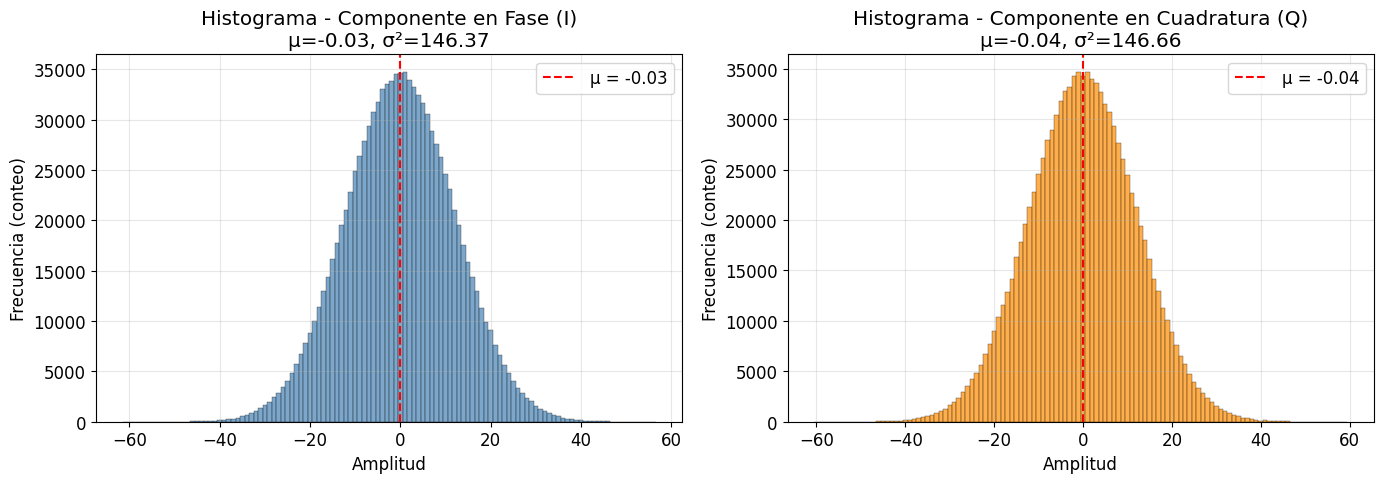

Histogramas construidos con 200 bins y 1048576 muestras.


In [39]:
# ========================================================================================
# Histograma de las componentes I y Q
# ========================================================================================

# Número de bins para el histograma
# Definición dinámica de bins (ancho = 1, centrados en enteros)
bins_I = np.arange(np.min(I), np.max(I) + 2) - 0.5
bins_Q = np.arange(np.min(Q), np.max(Q) + 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma de la componente en Fase (I) ---
axes[0].hist(I, bins=bins_I, color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Frecuencia (conteo)')
axes[0].set_title(f'Histograma - Componente en Fase (I)\nμ={mean_I:.2f}, σ²={var_I:.2f}')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=mean_I, color='red', linestyle='--', linewidth=1.5, label=f'μ = {mean_I:.2f}')
axes[0].legend()

# --- Histograma de la componente en Cuadratura (Q) ---
axes[1].hist(Q, bins=bins_Q, color='darkorange', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Frecuencia (conteo)')
axes[1].set_title(f'Histograma - Componente en Cuadratura (Q)\nμ={mean_Q:.2f}, σ²={var_Q:.2f}')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=mean_Q, color='red', linestyle='--', linewidth=1.5, label=f'μ = {mean_Q:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Histogramas construidos con {n_bins} bins y {N} muestras.")

---
## 8. Histograma normalizado

Para poder comparar el histograma con una función de densidad de probabilidad (PDF) teórica, necesitamos **normalizar** el histograma de forma que el **área encerrada sea igual a 1**.

Esto se logra usando el parámetro `density=True` en la función `hist()` de matplotlib, que normaliza los conteos dividiendo por el número total de muestras y por el ancho de cada bin. De esta forma, la integral del histograma es exactamente 1, cumpliendo con la definición de una función de densidad de probabilidad.

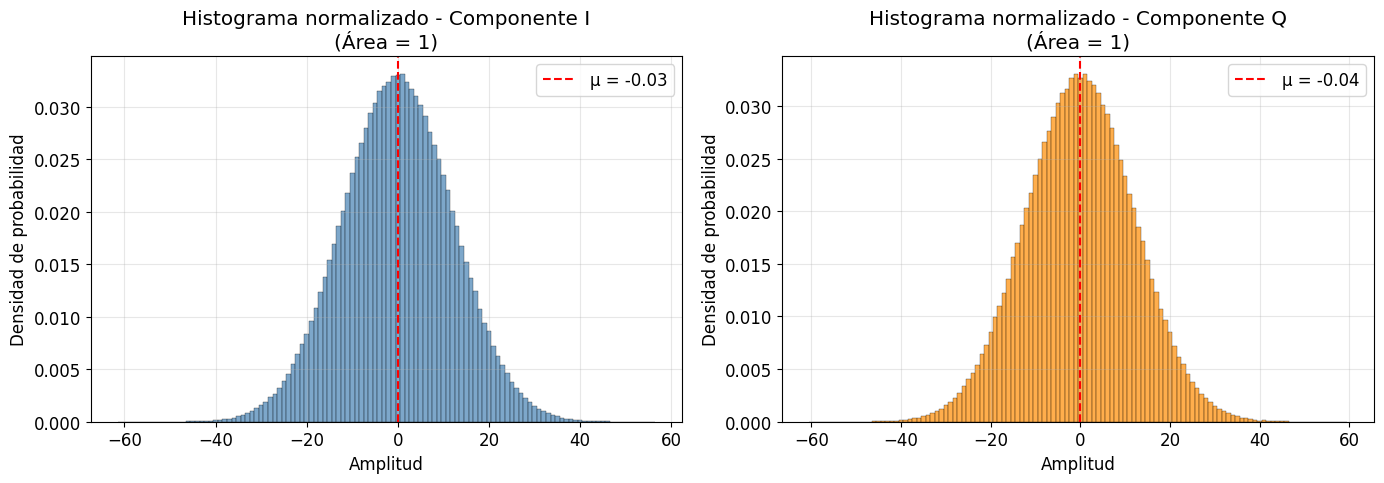

Los histogramas están normalizados: el área total bajo cada curva es igual a 1.
Esto permite la comparación directa con funciones de densidad de probabilidad (PDF) teóricas.


In [40]:
# ========================================================================================
# Histograma normalizado (área = 1)
# ========================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma normalizado de la componente en Fase (I) ---
axes[0].hist(I, bins=bins_I, density=True, color='steelblue', 
             edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Densidad de probabilidad')
axes[0].set_title(f'Histograma normalizado - Componente I\n(Área = 1)')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=mean_I, color='red', linestyle='--', linewidth=1.5, label=f'μ = {mean_I:.2f}')
axes[0].legend()

# --- Histograma normalizado de la componente en Cuadratura (Q) ---
axes[1].hist(Q, bins=bins_Q, density=True, color='darkorange', 
             edgecolor='black', linewidth=0.3, alpha=0.7)
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].set_title(f'Histograma normalizado - Componente Q\n(Área = 1)')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=mean_Q, color='red', linestyle='--', linewidth=1.5, label=f'μ = {mean_Q:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Los histogramas están normalizados: el área total bajo cada curva es igual a 1.")
print("Esto permite la comparación directa con funciones de densidad de probabilidad (PDF) teóricas.")

---
## 9. Superposición del histograma normalizado con la PDF gaussiana teórica

Ahora superponemos el histograma normalizado con la **función de densidad de probabilidad (PDF) gaussiana teórica** calculada con la misma media y varianza que los datos medidos.

La PDF de una distribución gaussiana está dada por:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Si el ruido es verdaderamente gaussiano, la curva teórica debería **ajustarse bien** al histograma normalizado.

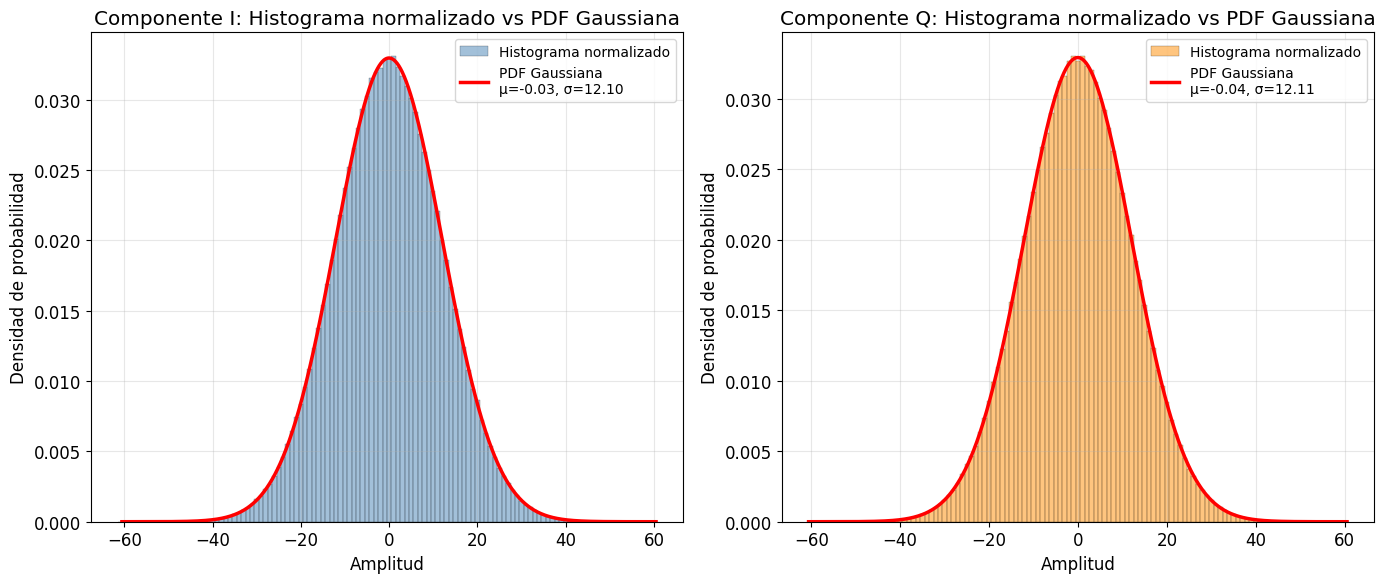

La línea roja representa la PDF gaussiana teórica con los mismos parámetros (μ, σ) que los datos.
Si el ajuste es bueno, se confirma la naturaleza gaussiana del ruido.


In [41]:
# ========================================================================================
# Superposición del histograma normalizado con la PDF gaussiana teórica
# ========================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Componente en Fase (I) ---
axes[0].hist(I, bins=bins_I, density=True, color='steelblue', 
             edgecolor='black', linewidth=0.3, alpha=0.5, label='Histograma normalizado')

x_I = np.linspace(mean_I - 5*std_I, mean_I + 5*std_I, 1000)
pdf_I = stats.norm.pdf(x_I, loc=mean_I, scale=std_I)
axes[0].plot(x_I, pdf_I, 'r-', linewidth=2.5, 
             label=f'PDF Gaussiana\nμ={mean_I:.2f}, σ={std_I:.2f}')

axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Densidad de probabilidad')
axes[0].set_title('Componente I: Histograma normalizado vs PDF Gaussiana')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Componente en Cuadratura (Q) ---
axes[1].hist(Q, bins=bins_Q, density=True, color='darkorange', 
             edgecolor='black', linewidth=0.3, alpha=0.5, label='Histograma normalizado')

x_Q = np.linspace(mean_Q - 5*std_Q, mean_Q + 5*std_Q, 1000)
pdf_Q = stats.norm.pdf(x_Q, loc=mean_Q, scale=std_Q)
axes[1].plot(x_Q, pdf_Q, 'r-', linewidth=2.5, 
             label=f'PDF Gaussiana\nμ={mean_Q:.2f}, σ={std_Q:.2f}')

axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].set_title('Componente Q: Histograma normalizado vs PDF Gaussiana')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("La línea roja representa la PDF gaussiana teórica con los mismos parámetros (μ, σ) que los datos.")
print("Si el ajuste es bueno, se confirma la naturaleza gaussiana del ruido.")

---
## 10. Análisis de gaussianidad - Gráfico Q-Q

El **gráfico Q-Q (Quantile-Quantile)** es una herramienta gráfica para evaluar si un conjunto de datos sigue una distribución teórica dada (en nuestro caso, la normal/gaussiana).

**¿Cómo se interpreta?**
- Se grafican los cuantiles de los datos empíricos vs. los cuantiles de la distribución teórica.
- Si los datos siguen la distribución teórica, **los puntos se alinean sobre una recta de 45°** (línea roja).
- Desviaciones de esta línea indican desviaciones de la gaussianidad:
  - Colas más pesadas que la gaussiana se manifiestan como puntos que se separan de la línea en los extremos.
  - Asimetría se manifiesta como curvatura en el gráfico.

Utilizamos la función `qqplot` del paquete `statsmodels`.

/home/yocamilo/Documents/Comunicaciones/LAB2/.venv/lib/python3.12/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


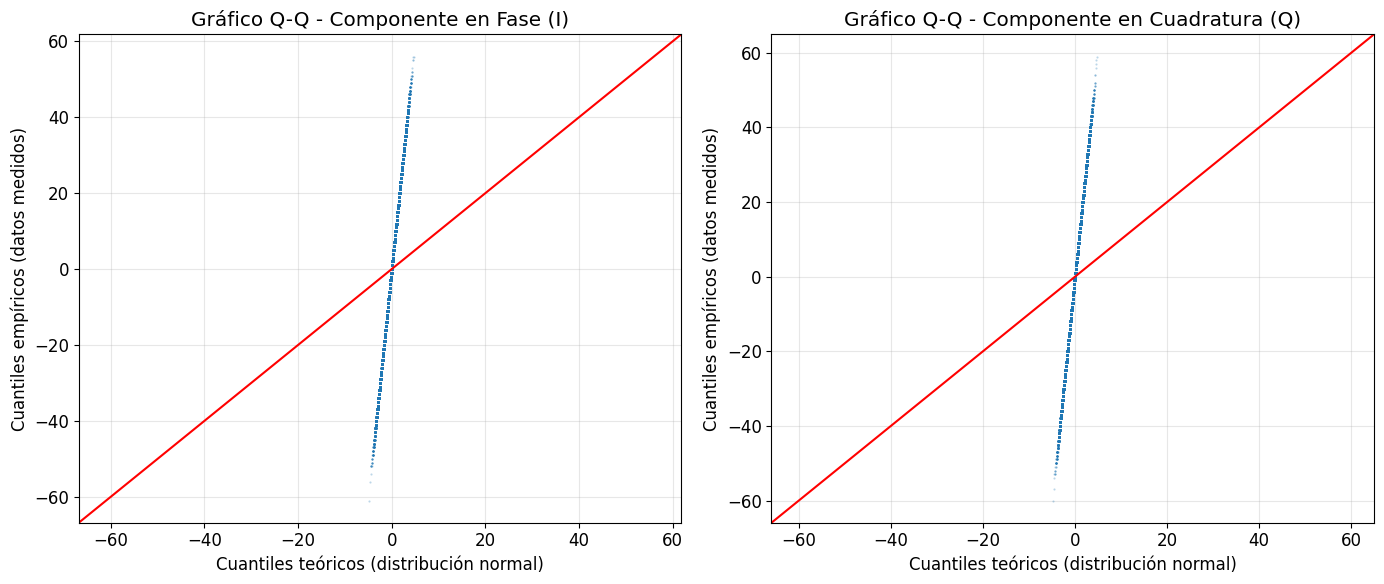

Interpretación del gráfico Q-Q:
  - Si los puntos se alinean sobre la línea roja de 45°, los datos son gaussianos.
  - Desviaciones en las colas indican diferencias en la distribución de extremos.
  - Curvatura general indica asimetría o diferente distribución.


In [42]:
# ========================================================================================
# Gráfico Q-Q para análisis de gaussianidad
# ========================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Q-Q Plot para la componente en Fase (I) ---
qqplot(I, line='45', ax=axes[0], markersize=0.5, alpha=0.3, color='steelblue')
axes[0].set_title('Gráfico Q-Q - Componente en Fase (I)')
axes[0].set_xlabel('Cuantiles teóricos (distribución normal)')
axes[0].set_ylabel('Cuantiles empíricos (datos medidos)')
axes[0].grid(True, alpha=0.3)

# --- Q-Q Plot para la componente en Cuadratura (Q) ---
qqplot(Q, line='45', ax=axes[1], markersize=0.5, alpha=0.3, color='darkorange')
axes[1].set_title('Gráfico Q-Q - Componente en Cuadratura (Q)')
axes[1].set_xlabel('Cuantiles teóricos (distribución normal)')
axes[1].set_ylabel('Cuantiles empíricos (datos medidos)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretación del gráfico Q-Q:")
print("  - Si los puntos se alinean sobre la línea roja de 45°, los datos son gaussianos.")
print("  - Desviaciones en las colas indican diferencias en la distribución de extremos.")
print("  - Curvatura general indica asimetría o diferente distribución.")

---
## 11. Generación de variable gaussiana compleja sintética

Generamos mediante código una **variable gaussiana compleja** que tenga la **misma media y varianza** que la señal muestreada del SDR.

Una variable gaussiana compleja $z = x + jy$ se construye como:
- $x \sim \mathcal{N}(\mu_I, \sigma_I^2)$: Parte real gaussiana con media $\mu_I$ y varianza $\sigma_I^2$
- $y \sim \mathcal{N}(\mu_Q, \sigma_Q^2)$: Parte imaginaria gaussiana con media $\mu_Q$ y varianza $\sigma_Q^2$

Donde $\mu_I$, $\sigma_I^2$, $\mu_Q$ y $\sigma_Q^2$ son los estadísticos obtenidos de la señal muestreada.

### 11.1 Generación de la señal sintética

In [34]:
# ========================================================================================
# Generación de variable gaussiana compleja sintética
# ========================================================================================

# Generamos N muestras gaussianas con la misma media y desviación estándar
# que las componentes I y Q medidas del SDR.

# Fijamos la semilla para reproducibilidad
np.random.seed(42)

# Componente en Fase sintética
I_synth = np.random.normal(loc=mean_I, scale=std_I, size=N)

# Componente en Cuadratura sintética
Q_synth = np.random.normal(loc=mean_Q, scale=std_Q, size=N)

# Señal compleja sintética
rxSignal_synth = I_synth + 1j * Q_synth

# Verificación de los estadísticos
print("=" * 70)
print("COMPARACIÓN DE ESTADÍSTICOS: SEÑAL MEDIDA vs SEÑAL SINTÉTICA")
print("=" * 70)
print(f"\n{'Parámetro':<30} {'Medida':>12} {'Sintética':>12}")
print(f"{'-'*54}")
print(f"{'Media I':<30} {mean_I:>12.4f} {np.mean(I_synth):>12.4f}")
print(f"{'Varianza I':<30} {var_I:>12.4f} {np.var(I_synth):>12.4f}")
print(f"{'Desv. Estándar I':<30} {std_I:>12.4f} {np.std(I_synth):>12.4f}")
print(f"{'Media Q':<30} {mean_Q:>12.4f} {np.mean(Q_synth):>12.4f}")
print(f"{'Varianza Q':<30} {var_Q:>12.4f} {np.var(Q_synth):>12.4f}")
print(f"{'Desv. Estándar Q':<30} {std_Q:>12.4f} {np.std(Q_synth):>12.4f}")

COMPARACIÓN DE ESTADÍSTICOS: SEÑAL MEDIDA vs SEÑAL SINTÉTICA

Parámetro                            Medida    Sintética
------------------------------------------------------
Media I                             -0.0315      -0.0488
Varianza I                          55.3536     146.4792
Desv. Estándar I                    12.0982      12.1029
Media Q                             -0.0429      -0.0483
Varianza Q                         146.6647     146.9736
Desv. Estándar Q                    12.1105      12.1233


### 11.2 Gráfica temporal de la señal sintética

Graficamos las componentes I y Q de la señal gaussiana sintética en el dominio del tiempo y las comparamos visualmente con las de la señal medida.

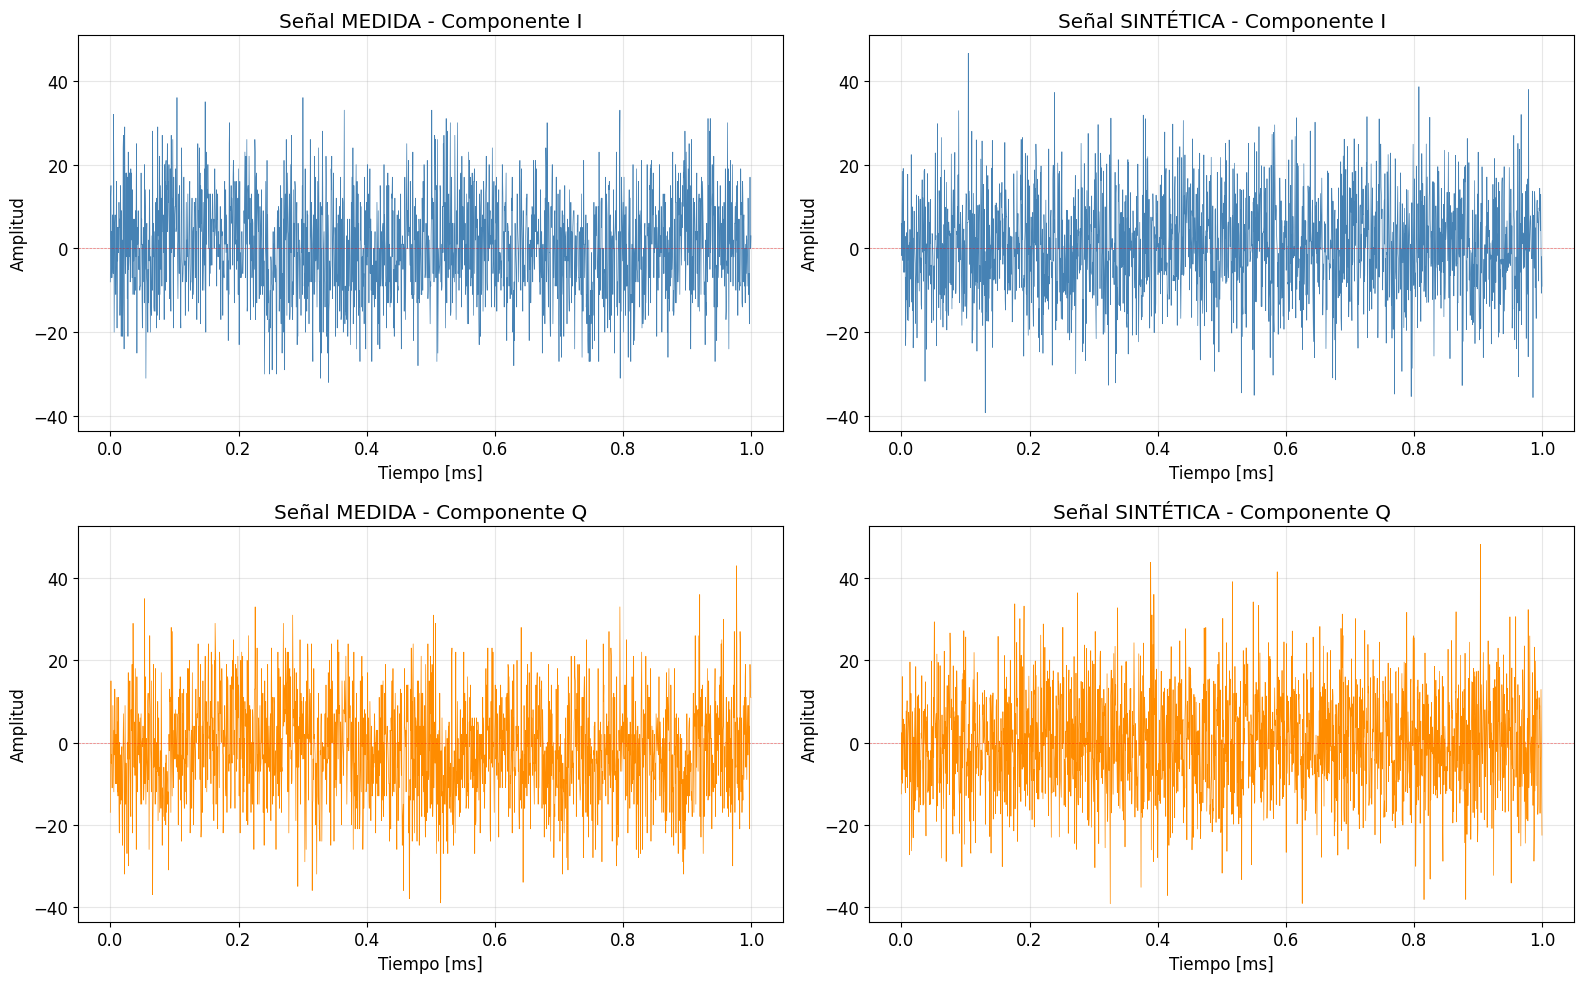

Columna izquierda: señal MEDIDA por el SDR (ruido real del canal).
Columna derecha:   señal SINTÉTICA generada con los mismos estadísticos.


In [35]:
# ========================================================================================
# Gráfica temporal de la señal sintética
# ========================================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Señal MEDIDA ---
axes[0, 0].plot(t[:n_display], I[:n_display], linewidth=0.5, color='steelblue')
axes[0, 0].set_xlabel('Tiempo [ms]')
axes[0, 0].set_ylabel('Amplitud')
axes[0, 0].set_title('Señal MEDIDA - Componente I')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[1, 0].plot(t[:n_display], Q[:n_display], linewidth=0.5, color='darkorange')
axes[1, 0].set_xlabel('Tiempo [ms]')
axes[1, 0].set_ylabel('Amplitud')
axes[1, 0].set_title('Señal MEDIDA - Componente Q')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# --- Señal SINTÉTICA ---
axes[0, 1].plot(t[:n_display], I_synth[:n_display], linewidth=0.5, color='steelblue')
axes[0, 1].set_xlabel('Tiempo [ms]')
axes[0, 1].set_ylabel('Amplitud')
axes[0, 1].set_title('Señal SINTÉTICA - Componente I')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[1, 1].plot(t[:n_display], Q_synth[:n_display], linewidth=0.5, color='darkorange')
axes[1, 1].set_xlabel('Tiempo [ms]')
axes[1, 1].set_ylabel('Amplitud')
axes[1, 1].set_title('Señal SINTÉTICA - Componente Q')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Igualar los ejes Y
for row in range(2):
    y_min = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
    y_max = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
    axes[row, 0].set_ylim([y_min, y_max])
    axes[row, 1].set_ylim([y_min, y_max])

plt.tight_layout()
plt.show()

print("Columna izquierda: señal MEDIDA por el SDR (ruido real del canal).")
print("Columna derecha:   señal SINTÉTICA generada con los mismos estadísticos.")

### 11.3 Gráfica en frecuencia de la señal sintética

Comparamos el espectro de frecuencia de la señal sintética con el de la señal medida.

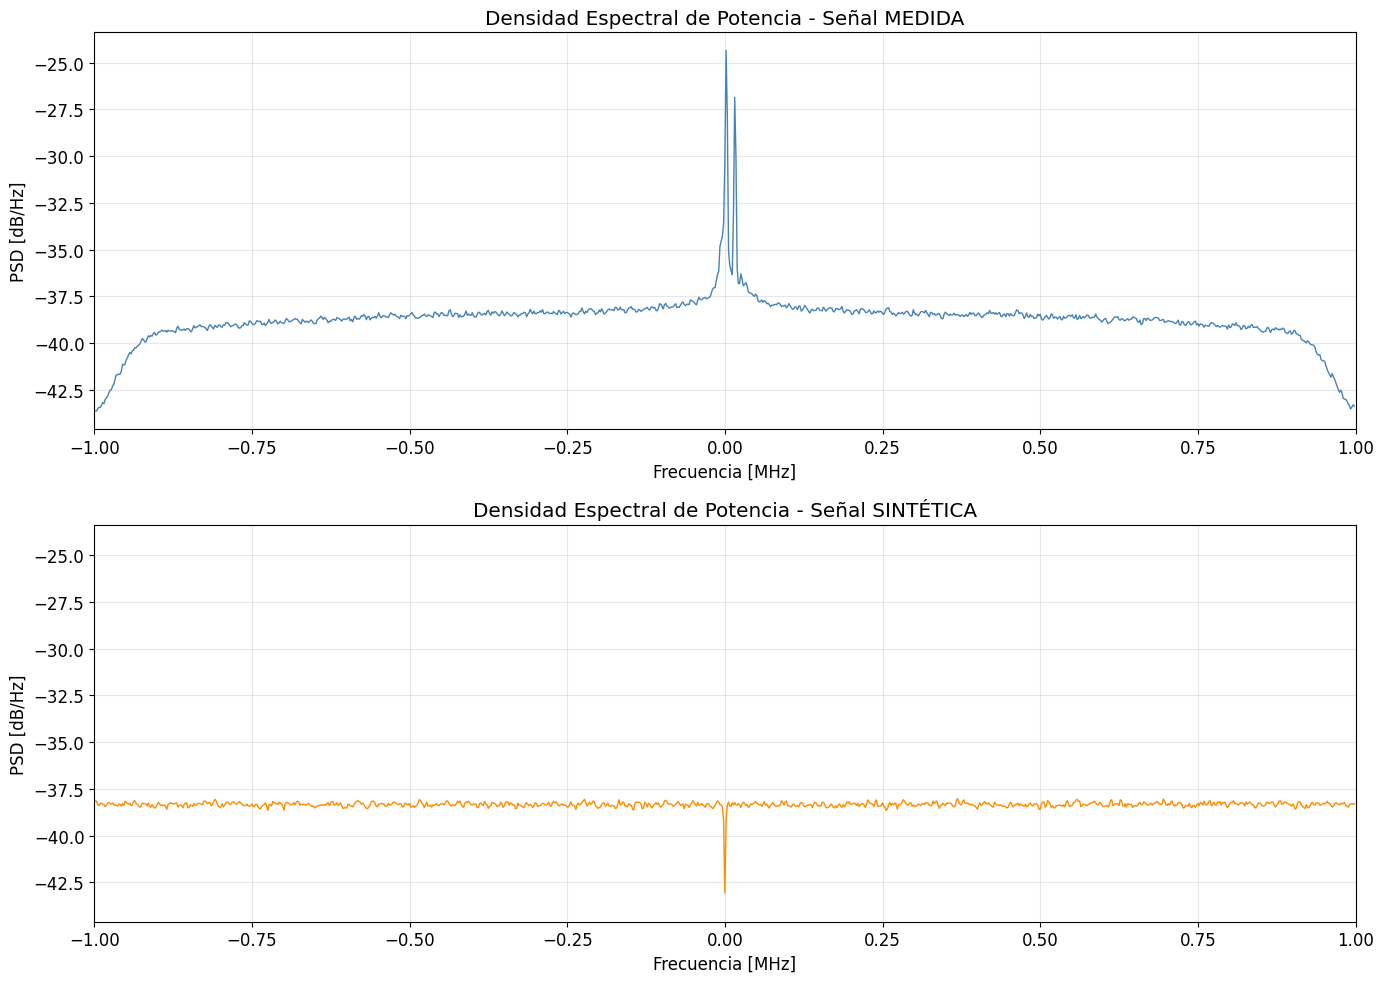

Comparación de la Densidad Espectral de Potencia (PSD):
  - La señal sintética (ruido blanco gaussiano puro) tiene un espectro plano.
  - La señal medida muestra variaciones debidas al filtro analógico del Rx.


In [36]:
# ========================================================================================
# Gráfica en frecuencia de la señal sintética vs señal medida
# ========================================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- PSD de la señal MEDIDA ---
f_meas, psd_meas = welch(rxSignal, fs=samplingRate, nperseg=1024, 
                          return_onesided=False, scaling='density')
f_meas = np.fft.fftshift(f_meas) / 1e6
psd_meas = np.fft.fftshift(psd_meas)
psd_meas_dB = 10 * np.log10(psd_meas + 1e-12)

axes[0].plot(f_meas, psd_meas_dB, linewidth=1.0, color='steelblue')
axes[0].set_xlabel('Frecuencia [MHz]')
axes[0].set_ylabel('PSD [dB/Hz]')
axes[0].set_title('Densidad Espectral de Potencia - Señal MEDIDA')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-samplingRate/2/1e6, samplingRate/2/1e6])

# --- PSD de la señal SINTÉTICA ---
f_synth, psd_synth = welch(rxSignal_synth, fs=samplingRate, nperseg=1024, 
                            return_onesided=False, scaling='density')
f_synth = np.fft.fftshift(f_synth) / 1e6
psd_synth = np.fft.fftshift(psd_synth)
psd_synth_dB = 10 * np.log10(psd_synth + 1e-12)

axes[1].plot(f_synth, psd_synth_dB, linewidth=1.0, color='darkorange')
axes[1].set_xlabel('Frecuencia [MHz]')
axes[1].set_ylabel('PSD [dB/Hz]')
axes[1].set_title('Densidad Espectral de Potencia - Señal SINTÉTICA')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-samplingRate/2/1e6, samplingRate/2/1e6])

# Igualar ejes Y
y_min = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
y_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim([y_min, y_max])
axes[1].set_ylim([y_min, y_max])

plt.tight_layout()
plt.show()

print("Comparación de la Densidad Espectral de Potencia (PSD):")
print("  - La señal sintética (ruido blanco gaussiano puro) tiene un espectro plano.")
print("  - La señal medida muestra variaciones debidas al filtro analógico del Rx.")

### 11.4 Histograma de la señal sintética

Comparamos los histogramas normalizados de las señales medida y sintética.

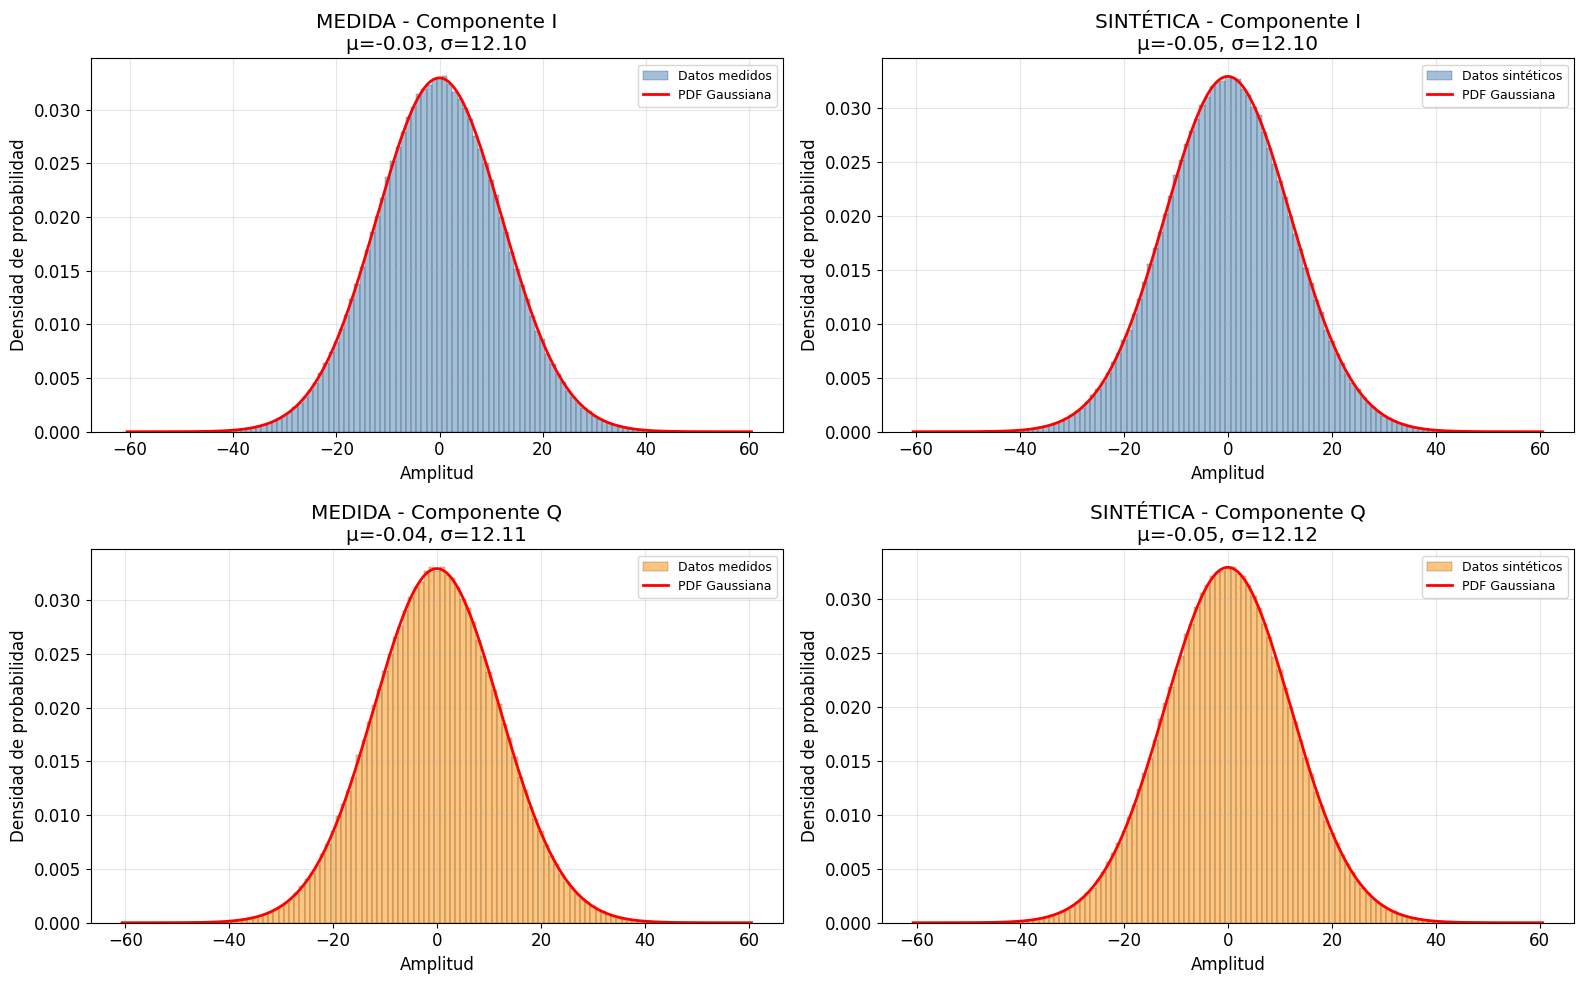

Columna izquierda: histogramas de la señal MEDIDA por el SDR.
Columna derecha:   histogramas de la señal SINTÉTICA generada.


In [37]:
# ========================================================================================
# Histograma de la señal sintética vs señal medida
# ========================================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Columna izquierda: Señal MEDIDA ---
axes[0, 0].hist(I, bins=bins_I, density=True, color='steelblue', 
                edgecolor='black', linewidth=0.3, alpha=0.5, label='Datos medidos')
axes[0, 0].plot(x_I, pdf_I, 'r-', linewidth=2, label=f'PDF Gaussiana')
axes[0, 0].set_xlabel('Amplitud')
axes[0, 0].set_ylabel('Densidad de probabilidad')
axes[0, 0].set_title(f'MEDIDA - Componente I\nμ={mean_I:.2f}, σ={std_I:.2f}')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].hist(Q, bins=bins_Q, density=True, color='darkorange', 
                edgecolor='black', linewidth=0.3, alpha=0.5, label='Datos medidos')
axes[1, 0].plot(x_Q, pdf_Q, 'r-', linewidth=2, label=f'PDF Gaussiana')
axes[1, 0].set_xlabel('Amplitud')
axes[1, 0].set_ylabel('Densidad de probabilidad')
axes[1, 0].set_title(f'MEDIDA - Componente Q\nμ={mean_Q:.2f}, σ={std_Q:.2f}')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# --- Columna derecha: Señal SINTÉTICA ---
bins_I_synth = np.arange(np.floor(np.min(I_synth)), np.ceil(np.max(I_synth)) + 2) - 0.5
bins_Q_synth = np.arange(np.floor(np.min(Q_synth)), np.ceil(np.max(Q_synth)) + 2) - 0.5
mean_Is = np.mean(I_synth)
std_Is = np.std(I_synth)
x_Is = np.linspace(mean_Is - 5*std_Is, mean_Is + 5*std_Is, 1000)
pdf_Is = stats.norm.pdf(x_Is, loc=mean_Is, scale=std_Is)

axes[0, 1].hist(I_synth, bins=bins_I_synth, density=True, color='steelblue', 
                edgecolor='black', linewidth=0.3, alpha=0.5, label='Datos sintéticos')
axes[0, 1].plot(x_Is, pdf_Is, 'r-', linewidth=2, label=f'PDF Gaussiana')
axes[0, 1].set_xlabel('Amplitud')
axes[0, 1].set_ylabel('Densidad de probabilidad')
axes[0, 1].set_title(f'SINTÉTICA - Componente I\nμ={mean_Is:.2f}, σ={std_Is:.2f}')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

mean_Qs = np.mean(Q_synth)
std_Qs = np.std(Q_synth)
x_Qs = np.linspace(mean_Qs - 5*std_Qs, mean_Qs + 5*std_Qs, 1000)
pdf_Qs = stats.norm.pdf(x_Qs, loc=mean_Qs, scale=std_Qs)

axes[1, 1].hist(Q_synth, bins=bins_Q_synth, density=True, color='darkorange', 
                edgecolor='black', linewidth=0.3, alpha=0.5, label='Datos sintéticos')
axes[1, 1].plot(x_Qs, pdf_Qs, 'r-', linewidth=2, label=f'PDF Gaussiana')
axes[1, 1].set_xlabel('Amplitud')
axes[1, 1].set_ylabel('Densidad de probabilidad')
axes[1, 1].set_title(f'SINTÉTICA - Componente Q\nμ={mean_Qs:.2f}, σ={std_Qs:.2f}')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Columna izquierda: histogramas de la señal MEDIDA por el SDR.")
print("Columna derecha:   histogramas de la señal SINTÉTICA generada.")

---
## 12. Limpieza de recursos

Liberamos los recursos del SDR para dejarlo en un estado limpio.

In [28]:
# ========================================================================================
# Limpieza de recursos del SDR
# ========================================================================================

# Destruir el buffer de transmisión y configurar el Tx para mínima interferencia
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89   # Máxima atenuación posible
sdr.tx_lo = int(2400e6)           # Alejar el Tx del Rx
sdr.rx_lo = int(950e6)            # Frecuencia Rx por defecto
sdr.tx(np.zeros(2048))            # Transmitir ceros

# Destruir el objeto SDR
del sdr

print("Recursos del SDR liberados correctamente.")

Recursos del SDR liberados correctamente.


---
## 13. Conclusiones

A partir de los resultados obtenidos en esta práctica de laboratorio, se pueden extraer las siguientes conclusiones:

### Sobre la naturaleza del ruido en el canal

1. **El ruido capturado exhibe características gaussianas**: Al observar los histogramas de las componentes en fase (I) y cuadratura (Q), se aprecia claramente la forma de campana característica de la distribución gaussiana. La superposición con la PDF teórica confirma un buen ajuste entre los datos empíricos y el modelo gaussiano.

2. **La media es aproximadamente cero**: Tanto la componente I como la Q presentan valores medios cercanos a cero, lo cual es consistente con el modelo teórico de ruido aditivo blanco gaussiano (AWGN) de media cero. Las pequeñas desviaciones respecto a cero se deben a imperfecciones del hardware, como el **DC offset** del receptor.

3. **Las varianzas de I y Q son similares**: La potencia de ruido se distribuye de manera aproximadamente equitativa entre ambas componentes, lo cual es consistente con la teoría de ruido circular complejo gaussiano (Circularly Symmetric Complex Gaussian, CSCG).

### Sobre el análisis espectral

4. **El espectro del ruido es relativamente plano**: La densidad espectral de potencia (PSD) muestra un comportamiento aproximadamente constante dentro del ancho de banda del receptor, lo cual es una característica del ruido blanco. Las variaciones observadas se deben al filtro analógico del receptor y a las limitaciones del hardware.

5. **Diferencias entre el espectro medido y el sintético**: El espectro de la señal sintética es más plano que el de la señal medida, ya que el ruido generado por software es ruido blanco puro, mientras que la señal medida pasa por los filtros del receptor que le dan forma al espectro.

### Sobre el análisis de gaussianidad (Q-Q Plot)

6. **Los gráficos Q-Q confirman la gaussianidad**: Los puntos se alinean mayoritariamente sobre la línea de 45°, confirmando que los datos siguen una distribución normal. Las pequeñas desviaciones en las colas pueden deberse a efectos no lineales del hardware del SDR o a interferencias externas leves.

### Sobre la señal sintética

7. **La señal sintética reproduce fielmente las características del ruido real**: La variable gaussiana compleja generada con los mismos parámetros estadísticos (media y varianza) que la señal muestreada muestra un comportamiento temporal, espectral e histogramático muy similar al del ruido capturado por el SDR.

8. **Diferencias sutiles**: La principal diferencia radica en el espectro: el ruido sintético tiene un espectro perfectamente plano (ruido blanco ideal), mientras que el ruido real muestra el efecto del filtro analógico del receptor. Además, la señal real puede contener un pequeño DC offset y posibles componentes espurias del hardware.

### Conclusión general

Los resultados de la práctica confirman que el **modelo de ruido aditivo blanco gaussiano (AWGN)** es una excelente aproximación para describir el ruido presente en un canal de comunicaciones inalámbrico. Este modelo, ampliamente utilizado en la teoría de comunicaciones, asume que el ruido es una variable aleatoria gaussiana de media cero e independiente de la señal transmitida, lo cual es consistente con las observaciones experimentales realizadas.

La capacidad de generar señales de ruido sintéticas que imitan las propiedades estadísticas del ruido real es fundamental para el diseño, simulación y evaluación de sistemas de comunicaciones digitales, ya que permite probar algoritmos de detección y decodificación sin necesidad de utilizar hardware físico.